# 04 — Model Training (v4)

Улучшения для повышения AUC:
- **5-дневный горизонт** (`target_up_5d`): предсказываем движение за 5 дней вместо 1 — убираем дневной шум
- **Порог таргета**: накопленный 5d return > 1% вместо 1d > 0.3%
- **Класс-балансировка** для XGBoost (`scale_pos_weight`) и LightGBM (`class_weight='balanced'`)
- **Optuna-тюнинг** XGBoost и LightGBM
- **Cross-sectional ранги** (7 признаков)
- Итого: ~43 признака на модель

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'backend'))

PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR    = ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA",
    "ORCL", "CRM", "ADBE", "AMD", "INTC", "QCOM", "TXN",
    "JPM", "BAC", "GS", "MS", "WFC", "BLK", "AXP",
    "JNJ", "UNH", "PFE", "ABT", "MRK", "TMO",
    "WMT", "HD", "MCD", "KO", "PG", "COST", "NKE",
    "XOM", "CVX", "CAT", "BA", "HON",
    "T", "VZ", "DIS", "V", "MA",
]

TRAIN_RATIO   = 0.8
HORIZON_DAYS  = 5
RETURN_THRESH = 0.01

print(f'Тикеров: {len(TICKERS)}')
print(f'Target: {HORIZON_DAYS}d forward cumulative return > {RETURN_THRESH:.1%}')

Тикеров: 44
Target: 5d forward cumulative return > 1.0%


## 1. Загрузка данных

In [2]:
def load_ticker(ticker: str) -> pd.DataFrame:
    path = PROCESSED_DIR / ticker / 'technical.parquet'
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_parquet(path)
    df['date']   = pd.to_datetime(df['date'])
    df['ticker'] = ticker
    return df.sort_values('date').reset_index(drop=True)


def make_target(df: pd.DataFrame, horizon: int = 5, threshold: float = 0.01) -> pd.DataFrame:
    """
    Таргет: накопленная доходность за следующие `horizon` дней > `threshold`.
    """
    df = df.copy()
    fwd_return = df['returns'].rolling(horizon).sum().shift(-horizon)
    df['target'] = (fwd_return > threshold).astype(int)
    return df.dropna(subset=['target', 'returns'])


frames = []
for ticker in TICKERS:
    df = load_ticker(ticker)
    if df.empty:
        print(f'[SKIP] {ticker}: нет данных')
        continue
    df = make_target(df, HORIZON_DAYS, RETURN_THRESH)
    frames.append(df)

if not frames:
    raise RuntimeError('Нет данных! Запустите 02_feature_engineering.ipynb')

combined = pd.concat(frames, ignore_index=True).sort_values('date').reset_index(drop=True)
print(f'Тикеров: {len(frames)}  Строк: {len(combined)}  Positive rate: {combined["target"].mean():.3f}')

Тикеров: 44  Строк: 54771  Positive rate: 0.415


## 2. Cross-sectional ранги

In [3]:
rank_source = ['returns', 'returns_3d', 'returns_10d', 'returns_20d', 'rsi', 'momentum',
               'volatility', 'volume_ratio', 'macd_hist', 'bb_pct', 'dist_52w_high', 'obv_change']

for feat in rank_source:
    if feat in combined.columns:
        combined[f'{feat}_rank'] = combined.groupby('date')[feat].rank(pct=True)

CROSS_FEATURES = [f'{f}_rank' for f in rank_source if f in combined.columns]
print(f'Cross-sectional ({len(CROSS_FEATURES)}): {CROSS_FEATURES}')

Cross-sectional (12): ['returns_rank', 'returns_3d_rank', 'returns_10d_rank', 'returns_20d_rank', 'rsi_rank', 'momentum_rank', 'volatility_rank', 'volume_ratio_rank', 'macd_hist_rank', 'bb_pct_rank', 'dist_52w_high_rank', 'obv_change_rank']


## 3. Train / Test split

In [4]:
split_idx = int(len(combined) * TRAIN_RATIO)
train = combined.iloc[:split_idx]
test  = combined.iloc[split_idx:]

print(f'Train: {len(train)}  ({train["date"].min().date()} – {train["date"].max().date()})  pos={train["target"].mean():.3f}')
print(f'Test:  {len(test)}   ({test["date"].min().date()} – {test["date"].max().date()})   pos={test["target"].mean():.3f}')

Train: 43816  (2021-04-16 – 2025-04-03)  pos=0.412
Test:  10955   (2025-04-03 – 2026-03-31)   pos=0.428


## 4. Обучение

In [5]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, brier_score_loss, average_precision_score,
)

from app.models.baseline_lr import BaselineLRModel
from app.models.model_a import ModelA
from app.models.model_b import ModelB
from app.models.model_c import ModelC
from app.models.model_d import ModelD
from app.features.constants import MACRO_FEATURES, SECTOR_FEATURES, PRICE_FEATURES

models = {
    'baseline_lr': BaselineLRModel(),
    'model_a':     ModelA(),
    'model_b':     ModelB(),
    'model_c':     ModelC(),
    'model_d':     ModelD(),
}

NON_FEATURE = {'date', 'ticker', 'target', 'close'}


def train_model(model, X_tr, y_tr, avail):
    inner = model.model
    pos = int(y_tr.sum())
    neg = int((y_tr == 0).sum())
    ratio = neg / pos if pos > 0 else 1.0
    if hasattr(inner, 'scale_pos_weight'):
        inner.set_params(scale_pos_weight=ratio)
    elif hasattr(inner, 'class_weight'):
        inner.set_params(class_weight='balanced')
    inner.fit(X_tr[avail], y_tr)
    model.is_trained = True
    model._nb_features = avail


def proba(model, X, avail):
    return model.model.predict_proba(X[avail])[:, 1]


def evaluate(model, X_te, y_te, avail):
    p    = proba(model, X_te, avail)
    pred = (p >= 0.5).astype(int)
    return {
        'f1':        round(f1_score(y_te, pred, zero_division=0), 4),
        'roc_auc':   round(roc_auc_score(y_te, p), 4),
        'precision': round(precision_score(y_te, pred, zero_division=0), 4),
        'recall':    round(recall_score(y_te, pred, zero_division=0), 4),
        'brier':     round(brier_score_loss(y_te, p), 4),
        'pr_auc':    round(average_precision_score(y_te, p), 4),
    }


# Макро-фичи — общие для всех тикеров, не ранжируются cross-sectionally
avail_macro   = [f for f in MACRO_FEATURES   if f in combined.columns]
avail_sector  = [f for f in SECTOR_FEATURES  if f in combined.columns]
avail_price   = [f for f in PRICE_FEATURES   if f in combined.columns]
print(f'Макро-фичи:   {len(avail_macro)}/{len(MACRO_FEATURES)}')
print(f'Сектор-фичи: {len(avail_sector)}/{len(SECTOR_FEATURES)}: {avail_sector}')
print(f'Price-фичи:  {len(avail_price)}/{len(PRICE_FEATURES)}: {avail_price}')

results   = {}
all_avail = {}

for name, model in models.items():
    avail = list(dict.fromkeys(
        [f for f in model.feature_set + CROSS_FEATURES + avail_macro + avail_sector + avail_price
         if f in combined.columns and f not in NON_FEATURE]
    ))
    all_avail[name] = avail

    X_tr = train[avail].fillna(0)
    X_te = test[avail].fillna(0)
    y_tr = train['target']
    y_te = test['target']

    print(f'[{name}] ({len(avail)} ф: {len(avail_macro)} макро + {len(avail_sector)} сект + {len(avail_price)} price)...', end=' ')
    train_model(model, X_tr, y_tr, avail)

    m = evaluate(model, X_te, y_te, avail)
    results[name] = m
    model.save(MODELS_DIR / f'{name}.joblib')
    print(f'F1={m["f1"]:.3f}  AUC={m["roc_auc"]:.3f}  Brier={m["brier"]:.4f}')

print('\nГотово!')

Макро-фичи:   9/9
Сектор-фичи: 5/5: ['ret1d_vs_sector', 'ret5d_vs_sector', 'sector_ret1d', 'sector_vol5d', 'sector_rsi']
Price-фичи:  8/8: ['returns_3d', 'returns_10d', 'returns_20d', 'dist_52w_high', 'dist_52w_low', 'volume_ratio', 'obv_change', 'bb_pct']
[baseline_lr] (47 ф: 9 макро + 5 сект + 8 price)... 

F1=0.492  AUC=0.526  Brier=0.2531
[model_a] (47 ф: 9 макро + 5 сект + 8 price)... 

F1=0.483  AUC=0.523  Brier=0.2549
[model_b] (47 ф: 9 макро + 5 сект + 8 price)... [LightGBM] [Info] Number of positive: 18061, number of negative: 25755
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001264 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9979
[LightGBM] [Info] Number of data points in the train set: 43816, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

F1=0.460  AUC=0.509  Brier=0.2612
[model_c] (47 ф: 9 макро + 5 сект + 8 price)... 

F1=0.435  AUC=0.534  Brier=0.2484
[model_d] (47 ф: 9 макро + 5 сект + 8 price)... 

F1=0.460  AUC=0.517  Brier=0.2551

Готово!


## 4b. Optuna-тюнинг XGBoost и LightGBM

In [6]:
import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score as _auc

optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_TRIALS = 40
CV_FOLDS      = 5

# Используем полный набор технических + cross-sectional фичей
_base_avail = all_avail.get('model_a', [])
_full_avail = all_avail.get('model_d', _base_avail)

X_tr_full = train[_full_avail].fillna(0)
y_tr_full = train['target']
X_te_full = test[_full_avail].fillna(0)
y_te_full = test['target']

pos = int(y_tr_full.sum())
neg = int((y_tr_full == 0).sum())
spw = neg / pos if pos > 0 else 1.0

tscv = TimeSeriesSplit(n_splits=CV_FOLDS)


def _cv_auc(clf, X, y):
    scores = []
    for tr_idx, val_idx in tscv.split(X):
        clf.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = clf.predict_proba(X.iloc[val_idx])[:, 1]
        scores.append(_auc(y.iloc[val_idx], p))
    return float(np.mean(scores))


# --- Optuna: XGBoost ---
def xgb_objective(trial):
    clf = XGBClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 100, 600),
        max_depth         = trial.suggest_int('max_depth', 3, 7),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        scale_pos_weight  = spw,
        eval_metric       = 'logloss',
        random_state      = 42,
    )
    return _cv_auc(clf, X_tr_full, y_tr_full)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)

best_xgb = XGBClassifier(**study_xgb.best_params, scale_pos_weight=spw,
                          eval_metric='logloss', random_state=42)
best_xgb.fit(X_tr_full, y_tr_full)
p_xgb = best_xgb.predict_proba(X_te_full)[:, 1]
auc_xgb = round(_auc(y_te_full, p_xgb), 4)
print(f'XGBoost (Optuna)  CV AUC={study_xgb.best_value:.4f}  Holdout AUC={auc_xgb}')
import joblib; joblib.dump(best_xgb, MODELS_DIR / 'model_xgb_optuna.joblib')


# --- Optuna: LightGBM ---
def lgbm_objective(trial):
    clf = LGBMClassifier(
        n_estimators    = trial.suggest_int('n_estimators', 100, 600),
        num_leaves      = trial.suggest_int('num_leaves', 20, 150),
        max_depth       = trial.suggest_int('max_depth', 3, 8),
        learning_rate   = trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        feature_fraction= trial.suggest_float('feature_fraction', 0.5, 1.0),
        bagging_fraction= trial.suggest_float('bagging_fraction', 0.5, 1.0),
        bagging_freq    = trial.suggest_int('bagging_freq', 1, 7),
        reg_alpha       = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        reg_lambda      = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        class_weight    = 'balanced',
        random_state    = 42,
        verbosity       = -1,
    )
    return _cv_auc(clf, X_tr_full, y_tr_full)

study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(lgbm_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)

best_lgbm = LGBMClassifier(**study_lgbm.best_params, class_weight='balanced',
                            random_state=42, verbosity=-1)
best_lgbm.fit(X_tr_full, y_tr_full)
p_lgbm = best_lgbm.predict_proba(X_te_full)[:, 1]
auc_lgbm = round(_auc(y_te_full, p_lgbm), 4)
print(f'LightGBM (Optuna) CV AUC={study_lgbm.best_value:.4f}  Holdout AUC={auc_lgbm}')
joblib.dump(best_lgbm, MODELS_DIR / 'model_lgbm_optuna.joblib')


# Добавляем в общие результаты
results['xgb_optuna']  = {'roc_auc': auc_xgb,  'f1': round(f1_score(y_te_full, (p_xgb >= 0.5).astype(int), zero_division=0), 4)}
results['lgbm_optuna'] = {'roc_auc': auc_lgbm, 'f1': round(f1_score(y_te_full, (p_lgbm >= 0.5).astype(int), zero_division=0), 4)}

print(f'\nЛучший: {"XGBoost" if auc_xgb >= auc_lgbm else "LightGBM"} (AUC={max(auc_xgb, auc_lgbm)})')

XGBoost (Optuna)  CV AUC=0.5342  Holdout AUC=0.5461


LightGBM (Optuna) CV AUC=0.5336  Holdout AUC=0.5352

Лучший: XGBoost (AUC=0.5461)


## 5. Метрики и графики

                 f1  roc_auc  precision  recall   brier  pr_auc
baseline_lr  0.4924   0.5257     0.4472  0.5477  0.2531  0.4415
model_a      0.4831   0.5234     0.4531  0.5174  0.2549  0.4470
model_b      0.4603   0.5091     0.4395  0.4830  0.2612  0.4397
model_c      0.4353   0.5343     0.4532  0.4186  0.2484  0.4559
model_d      0.4597   0.5175     0.4426  0.4781  0.2551  0.4428
xgb_optuna   0.4926   0.5461        NaN     NaN     NaN     NaN
lgbm_optuna  0.4764   0.5352        NaN     NaN     NaN     NaN


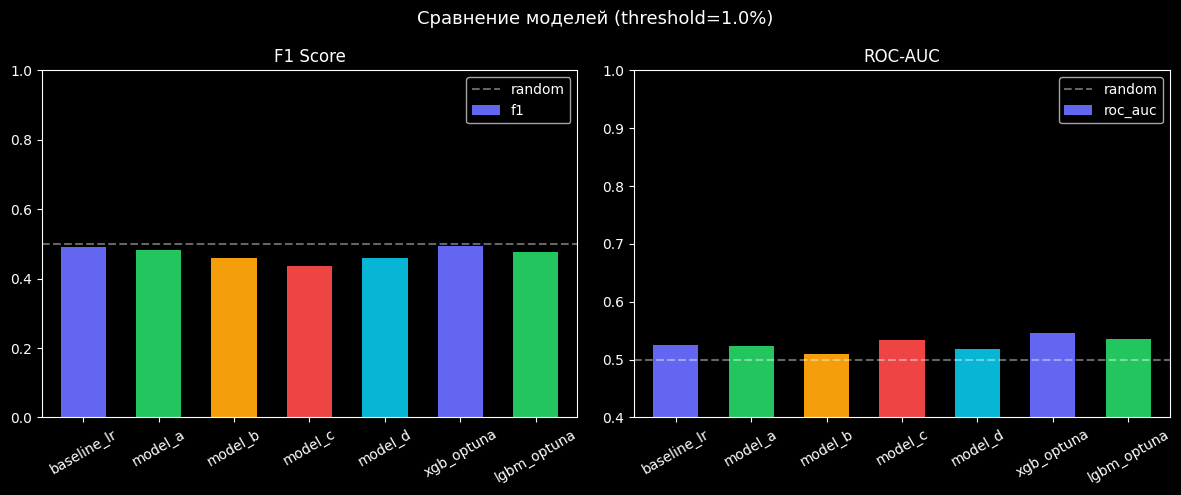

In [7]:
metrics_df = pd.DataFrame(results).T
print(metrics_df[['f1', 'roc_auc', 'precision', 'recall', 'brier', 'pr_auc']].round(4).to_string())

colors = ['#6366f1', '#22c55e', '#f59e0b', '#ef4444', '#06b6d4']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

metrics_df['f1'].plot(kind='bar', ax=axes[0], color=colors[:len(metrics_df)], width=0.6)
axes[0].set_title('F1 Score')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='white', linestyle='--', alpha=0.4, label='random')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

metrics_df['roc_auc'].plot(kind='bar', ax=axes[1], color=colors[:len(metrics_df)], width=0.6)
axes[1].set_title('ROC-AUC')
axes[1].set_ylim(0.4, 1)
axes[1].axhline(0.5, color='white', linestyle='--', alpha=0.4, label='random')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f'Сравнение моделей (threshold={RETURN_THRESH:.1%})', fontsize=13)
plt.tight_layout()
plt.show()

## 6. ROC-кривые

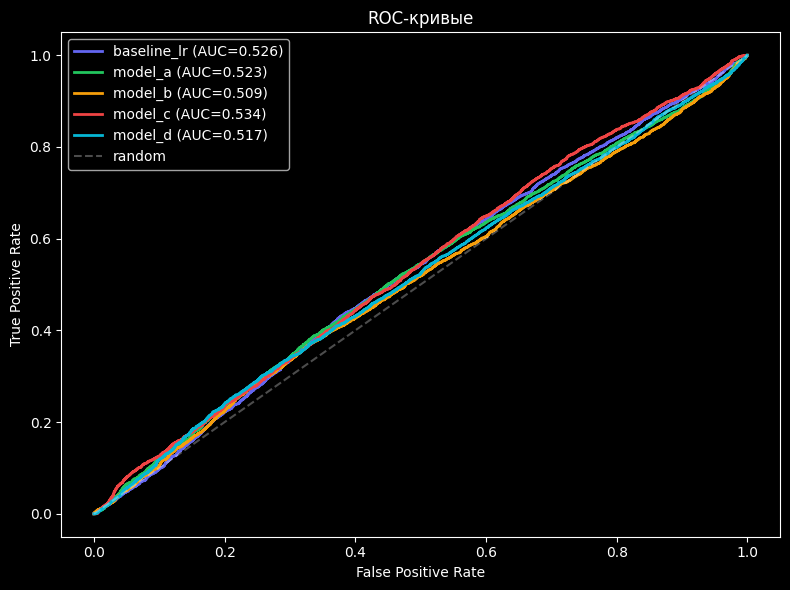

In [8]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(models.items(), colors):
    if name not in results:
        continue
    avail = all_avail[name]
    p     = proba(model, test[avail].fillna(0), avail)
    fpr, tpr, _ = roc_curve(test['target'], p)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={results[name]["roc_auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'w--', alpha=0.3, label='random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-кривые')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature importance

Доля cross-sectional: 15.3%
Топ-5: ['vix_level', 'qqq_return', 'spy_vol_5d', 'vix_change', 'vix_spy_ratio']


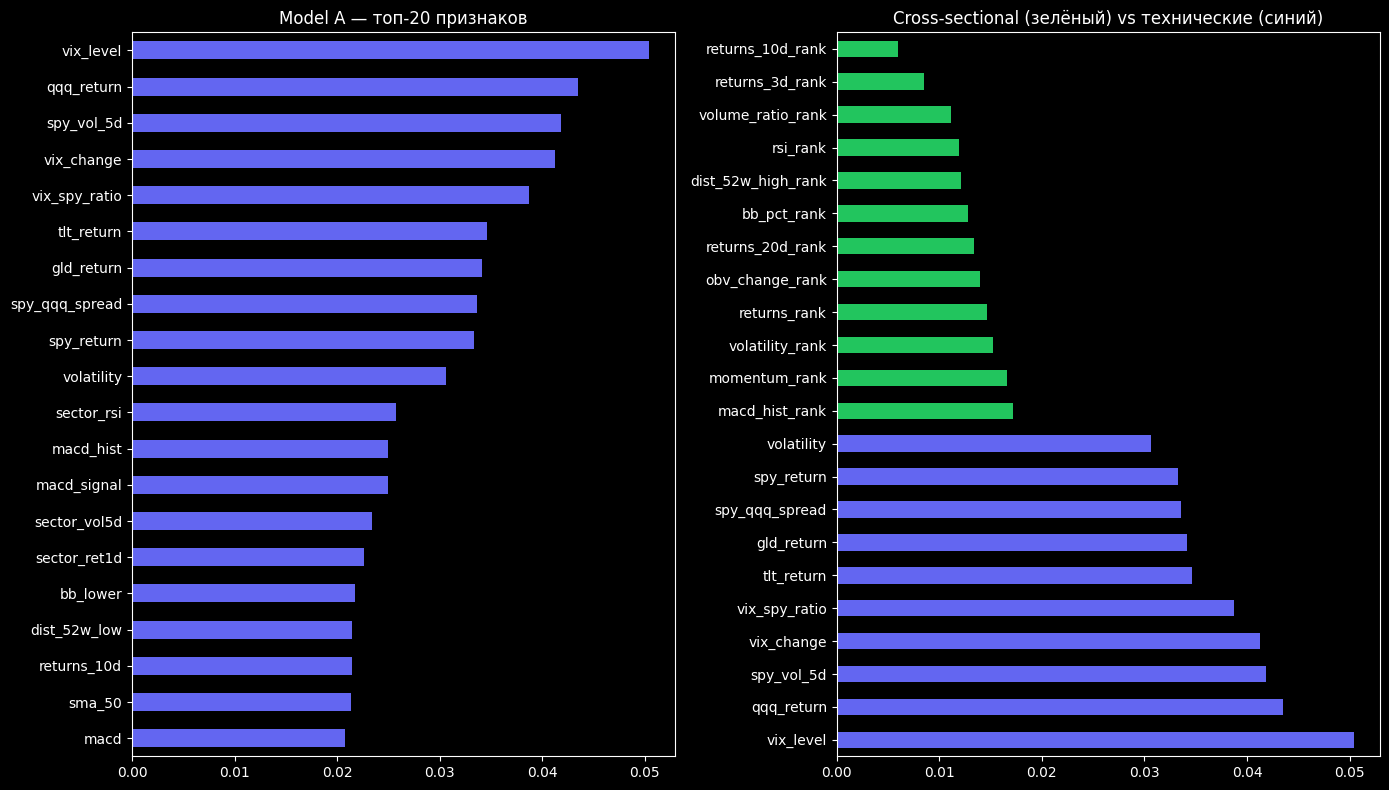

In [9]:
if 'model_a' in results:
    model_a = models['model_a']
    avail   = all_avail['model_a']
    fi = pd.Series(model_a.model.feature_importances_, index=avail).sort_values(ascending=False)

    fi_cross = fi[[f for f in fi.index if f.endswith('_rank')]]
    fi_base  = fi[[f for f in fi.index if not f.endswith('_rank')]]

    print(f'Доля cross-sectional: {fi_cross.sum() / fi.sum():.1%}')
    print(f'Топ-5: {fi.head().index.tolist()}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))

    fi.head(20).plot(kind='barh', ax=axes[0], color='#6366f1')
    axes[0].set_title('Model A — топ-20 признаков')
    axes[0].invert_yaxis()

    combined_fi = pd.concat([fi_cross, fi_base.head(10)]).sort_values()
    bar_colors  = ['#22c55e' if f.endswith('_rank') else '#6366f1' for f in combined_fi.index]
    combined_fi.plot(kind='barh', ax=axes[1], color=bar_colors)
    axes[1].set_title('Cross-sectional (зелёный) vs технические (синий)')
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

## 8. Calibration curves

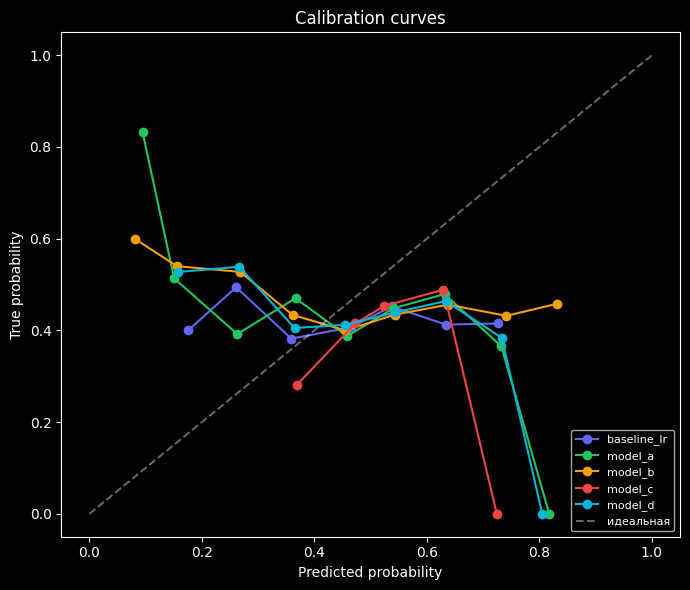

In [10]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

for (name, model), color in zip(models.items(), colors):
    if name not in results:
        continue
    avail = all_avail[name]
    p     = proba(model, test[avail].fillna(0), avail)
    prob_true, prob_pred = calibration_curve(test['target'], p, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', color=color, label=name, lw=1.5)

ax.plot([0, 1], [0, 1], 'w--', alpha=0.4, label='идеальная')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('True probability')
ax.set_title('Calibration curves')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()